# ADF Stationarity & Granger Causality — Lag Feature Selection

**Dataset**: `final_clean_dataset_long.csv` (2023–2026, 90–105 weekly auctions per catalogue)

**Goal**: Determine which lagged weather features (precipitation, temperature, sunshine)
Granger-cause tea auction prices in each catalogue, and recommend which lag columns
(`_lag1 / _lag2 / _lag3`) to retain in the ML feature set.

**Workflow**:
1. Aggregate `price_mid_lkr` and weather columns to sale-level time series per catalogue.
2. **ADF test** (AIC lag selection) — flag non-stationary series for first-differencing.
3. **Granger causality** at lags 1–4 weeks using SSR F-test.
4. ACF / PACF plots to assess price autocorrelation structure.
5. Feature selection recommendation table for each catalogue.

Significance: `***` p<0.01 · `**` p<0.05 · `*` p<0.10 · `(t)` p<0.15

## 1. Setup & Data Loading

In [1]:
import numpy as np
import pandas as pd
from pathlib import Path
from statsmodels.tsa.stattools import grangercausalitytests, adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from IPython.display import display

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 140)
plt.rcParams.update({
    'figure.dpi': 120, 'font.size': 9, 'axes.titlesize': 10,
    'axes.labelsize': 9, 'xtick.labelsize': 8, 'ytick.labelsize': 8,
    'legend.fontsize': 8, 'axes.spines.top': False, 'axes.spines.right': False,
})

DATA_PATH  = Path('../data/processed-2024/final_clean_dataset_long.csv')
OUTPUT_DIR = Path('../data/processed-2024')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

MAX_LAG = 3
CATALOGUES = ['high_grown', 'low_grown', 'off_grade', 'dust']
DISP = {'high_grown': 'High Grown', 'low_grown': 'Low Grown',
        'off_grade': 'Off-Grade',  'dust': 'Dust'}

# Weather variable -> reconstructed-current column name (built in next cell)
WEATHER_VARS = {
    'Precipitation': 'precip_current',
    'Temperature':   'temperature_current',
    'Sunshine':      'sunshine_current',
}

print(f'Libraries loaded.  MAX_LAG = {MAX_LAG}')

Libraries loaded.  MAX_LAG = 3


In [2]:
# ── 1. Load & aggregate to sale × catalogue level ────────────────────────────
df_raw = pd.read_csv(DATA_PATH)
df_raw = df_raw.replace([np.inf, -np.inf], np.nan)
df_raw = df_raw.dropna(subset=['price_mid_lkr', 'catalogue']).copy()
df_raw = df_raw.sort_values(['sale_year', 'sale_number']).reset_index(drop=True)

sale_ts_all = (
    df_raw.groupby(['catalogue', 'sale_year', 'sale_number'])
    .agg(
        price_mid_lkr       = ('price_mid_lkr',                'mean'),
        temperature_current = ('temperature_2m_mean_mean',     'first'),
        temperature_lag1    = ('temperature_2m_mean_mean_lag1','first'),
        temperature_lag2    = ('temperature_2m_mean_mean_lag2','first'),
        temperature_lag3    = ('temperature_2m_mean_mean_lag3','first'),
        precipitation_lag1  = ('precipitation_sum_total_lag1', 'first'),
        precipitation_lag2  = ('precipitation_sum_total_lag2', 'first'),
        precipitation_lag3  = ('precipitation_sum_total_lag3', 'first'),
        sunshine_lag1       = ('sunshine_duration_total_lag1', 'first'),
        sunshine_lag2       = ('sunshine_duration_total_lag2', 'first'),
        sunshine_lag3       = ('sunshine_duration_total_lag3', 'first'),
        avg_weather_severity= ('avg_weather_severity',         'first'),
        fx_usd              = ('fx_usd',                       'first'),
    )
    .reset_index()
    .sort_values(['catalogue', 'sale_year', 'sale_number'])
    .reset_index(drop=True)
)

# ── Reconstruct current-week precip/sunshine from lag1 ────────────────────────
# lag1[t] = value at (t-1)  =>  current[t] = lag1[t+1]  =>  shift(-1) per catalogue
for cat in CATALOGUES:
    cm = sale_ts_all['catalogue'] == cat
    sale_ts_all.loc[cm, 'precip_current']  = sale_ts_all.loc[cm, 'precipitation_lag1'].shift(-1).values
    sale_ts_all.loc[cm, 'sunshine_current'] = sale_ts_all.loc[cm, 'sunshine_lag1'].shift(-1).values

# ── Per-catalogue time series dict ────────────────────────────────────────────
catalogue_ts = {}
for cat in CATALOGUES:
    ts = sale_ts_all[sale_ts_all['catalogue'] == cat].copy().reset_index(drop=True)
    ts['time_idx'] = range(len(ts))
    catalogue_ts[cat] = ts

print(f'{"Catalogue":<15} {"N sales":>8}  {"Price range LKR":>22}  Years')
print('-' * 65)
for cat in CATALOGUES:
    ts = catalogue_ts[cat]
    print(f'{DISP[cat]:<15} {len(ts):>8}  '
          f'{ts["price_mid_lkr"].min():.0f} – {ts["price_mid_lkr"].max():.0f} LKR'
          f'  {int(ts["sale_year"].min())}–{int(ts["sale_year"].max())}')

Catalogue        N sales         Price range LKR  Years
-----------------------------------------------------------------
High Grown            90  1019 – 1459 LKR  2023–2026
Low Grown            104  1366 – 1795 LKR  2023–2026
Off-Grade            105  724 – 938 LKR  2023–2026
Dust                 105  856 – 1048 LKR  2023–2026


## 2. Stationarity Testing (ADF)

Granger causality requires weak stationarity. ADF applied to price and weather series per catalogue.

Non-stationary series (p ≥ 0.05) are first-differenced before Granger testing.

In [3]:
# ── 2. ADF Stationarity Tests ────────────────────────────────────────────────
def adf_result(series, alpha=0.05):
    clean = series.dropna()
    if len(clean) < 8 or clean.std() == 0:
        return False, np.nan
    stat, p, *_ = adfuller(clean, autolag='AIC')
    return (p < alpha), round(p, 4)

print(f'{"Series":<40} {"ADF p-val":>10} {"Stationary?":>12} {"Action":>10}')
print('-' * 80)

stationarity_decisions = {}

for cat in CATALOGUES:
    ts = catalogue_ts[cat]
    decs = {}

    stat_p, p_p = adf_result(ts['price_mid_lkr'])
    print(f'{DISP[cat]+" Price":<40} {p_p:>10.4f} {str(stat_p):>12} {"levels" if stat_p else "diff":>10}')
    decs['price_diff'] = not stat_p

    for var_name, col in WEATHER_VARS.items():
        s_w = ts[col].dropna() if col in ts.columns else pd.Series(dtype=float)
        stat_w, p_w = adf_result(s_w)
        label = f'  {DISP[cat]} {var_name}'
        print(f'{label:<40} {p_w:>10.4f} {str(stat_w):>12} {"levels" if stat_w else "diff":>10}')
        decs[f'{var_name}_diff'] = not stat_w

    stationarity_decisions[cat] = decs
    print()

Series                                    ADF p-val  Stationary?     Action
--------------------------------------------------------------------------------
High Grown Price                             0.0007         True     levels
  High Grown Precipitation                   0.0000         True     levels
  High Grown Temperature                     0.0453         True     levels
  High Grown Sunshine                           nan        False       diff

Low Grown Price                              0.1087        False       diff
  Low Grown Precipitation                    0.0000         True     levels
  Low Grown Temperature                      0.0459         True     levels
  Low Grown Sunshine                         0.0000         True     levels

Off-Grade Price                              0.0325         True     levels
  Off-Grade Precipitation                    0.0000         True     levels
  Off-Grade Temperature                      0.0000         True     levels
  Off

## 3. Granger Causality Tests (Lags 1–4)

For each **(catalogue, weather variable, lag)** triplet:
- Apply differencing as indicated by ADF
- `grangercausalitytests` with `maxlag = 4`
- Report **SSR F-test** statistic and p-value

**H₀**: Weather does NOT Granger-cause price (past weather gives no extra predictive power)  
**H₁**: Weather Granger-causes price (reject H₀ at chosen α)

In [4]:
# ── 3. Granger Causality Tests ───────────────────────────────────────────────
def sig_marker(p):
    if pd.isna(p):  return 'N/A'
    if p < 0.01:    return '***'
    elif p < 0.05:  return '**'
    elif p < 0.10:  return '*'
    elif p < 0.15:  return '(t)'
    return ''

def run_granger(y_series, x_series, maxlag):
    data = pd.concat([y_series.rename('y'), x_series.rename('x')], axis=1).dropna()
    if len(data) < maxlag + 6:
        return {lag: (np.nan, np.nan) for lag in range(1, maxlag + 1)}
    try:
        res = grangercausalitytests(data[['y', 'x']], maxlag=maxlag, verbose=False)
        return {lag: (round(res[lag][0]['ssr_ftest'][0], 3),
                      round(res[lag][0]['ssr_ftest'][1], 4))
                for lag in range(1, maxlag + 1)}
    except Exception:
        return {lag: (np.nan, np.nan) for lag in range(1, maxlag + 1)}

records = []

for cat in CATALOGUES:
    ts   = catalogue_ts[cat]
    decs = stationarity_decisions[cat]
    y = ts['price_mid_lkr'].diff().dropna() if decs['price_diff'] else ts['price_mid_lkr']

    for var_name, col in WEATHER_VARS.items():
        x = ts[col] if col in ts.columns else pd.Series(dtype=float)
        if decs.get(f'{var_name}_diff', False):
            x = x.diff().dropna()

        lag_res = run_granger(y, x, MAX_LAG)

        for lag, (f_stat, p_val) in lag_res.items():
            records.append({
                'catalogue':   cat,
                'cat_display': DISP[cat],
                'weather_var': var_name,
                'lag':         lag,
                'F_stat':      f_stat,
                'p_value':     p_val,
                'sig':         sig_marker(p_val),
                'price_diff':  decs['price_diff'],
                'w_diff':      decs.get(f'{var_name}_diff', False),
            })

results_df = pd.DataFrame(records)
print(f'Total tests: {len(results_df)}  (4 catalogues x 3 vars x {MAX_LAG} lags)')
print(f'  p<0.01: {(results_df["p_value"]<0.01).sum()}')
print(f'  p<0.05: {(results_df["p_value"]<0.05).sum()}')
print(f'  p<0.10: {(results_df["p_value"]<0.10).sum()}')

Total tests: 36  (4 catalogues x 3 vars x 3 lags)
  p<0.01: 0
  p<0.05: 10
  p<0.10: 12


c:\Users\User\Desktop\DS-Research\.venv\Lib\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


## 4. Detailed Results by Catalogue

In [5]:
# ── 4. Detailed Results by Catalogue ─────────────────────────────────────────
print('=' * 108)
print('GRANGER CAUSALITY: Weather -> Tea Price   (F-statistic [p-value])')
print('H0: Weather does NOT Granger-cause price | *** p<0.01  ** p<0.05  * p<0.10  (t) p<0.15')
print('=' * 108)

for cat in CATALOGUES:
    decs = stationarity_decisions[cat]
    n    = len(catalogue_ts[cat])
    dnote = ' (price 1st-diff)' if decs['price_diff'] else ''
    print(f'\n{DISP[cat]}  [n = {n} sales{dnote}]')
    hdr = '  '.join([f'{"Lag "+str(l):>24}' for l in range(1, MAX_LAG + 1)])
    print(f'  {"Weather Variable":<20}  {hdr}')
    print('  ' + '-' * 112)

    for var_name in ['Precipitation', 'Temperature', 'Sunshine']:
        sub = results_df[
            (results_df['catalogue'] == cat) & (results_df['weather_var'] == var_name)
        ].sort_values('lag')
        cells = []
        for _, r in sub.iterrows():
            cell = 'N/A' if pd.isna(r['F_stat']) else \
                   f"{r['F_stat']:.3f} [{r['p_value']:.3f}]{r['sig']}"
            cells.append(f'{cell:>24}')
        print(f'  {var_name:<20}  ' + '  '.join(cells))

print('\n' + '=' * 108)

GRANGER CAUSALITY: Weather -> Tea Price   (F-statistic [p-value])
H0: Weather does NOT Granger-cause price | *** p<0.01  ** p<0.05  * p<0.10  (t) p<0.15

High Grown  [n = 90 sales]
  Weather Variable                         Lag 1                     Lag 2                     Lag 3
  ----------------------------------------------------------------------------------------------------------------
  Precipitation                    1.899 [0.172]             0.892 [0.414]             1.471 [0.229]
  Temperature                      1.717 [0.194]             0.906 [0.408]             0.563 [0.641]
  Sunshine                                   N/A                       N/A                       N/A

Low Grown  [n = 104 sales (price 1st-diff)]
  Weather Variable                         Lag 1                     Lag 2                     Lag 3
  ----------------------------------------------------------------------------------------------------------------
  Precipitation                  5.275 

## 5. IEEE Summary Table & Significant Findings

In [6]:
# ── 5. IEEE Summary Table + Significant Findings ─────────────────────────────
pivot_rows = []
for cat in CATALOGUES:
    for var_name in ['Precipitation', 'Temperature', 'Sunshine']:
        row = {'Catalogue': DISP[cat], 'Weather Var': var_name}
        sub = results_df[
            (results_df['catalogue'] == cat) & (results_df['weather_var'] == var_name)
        ].sort_values('lag')
        for _, r in sub.iterrows():
            lag = int(r['lag'])
            row[f'Lag {lag}'] = 'N/A' if pd.isna(r['F_stat']) else \
                                f"{r['F_stat']:.2f} [{r['p_value']:.3f}]{r['sig']}"
        pivot_rows.append(row)

summary_tbl = pd.DataFrame(pivot_rows)
print('GRANGER CAUSALITY — IEEE FORMAT')
print('(F [p], *** p<0.01  ** p<0.05  * p<0.10)')
display(summary_tbl)

# Significant findings
sig_df = results_df[results_df['p_value'] < 0.10].sort_values(['catalogue','weather_var','lag'])
print('\nSIGNIFICANT RELATIONSHIPS (p < 0.10):')
print('-' * 78)
if sig_df.empty:
    print('  None at p < 0.10')
else:
    for _, r in sig_df.iterrows():
        print(f'  {r["cat_display"]:<15} | {r["weather_var"]:<15} | '
              f'Lag {int(r["lag"])} | F={r["F_stat"]:.3f}  p={r["p_value"]:.4f} {r["sig"]}')

# Best lag per pair
print('\nBEST LAG (lowest p) per Catalogue x Variable:')
print('-' * 78)
best_idx = results_df.dropna(subset=['p_value']).groupby(['cat_display','weather_var'])['p_value'].idxmin()
best_lags = results_df.loc[best_idx, ['cat_display','weather_var','lag','F_stat','p_value','sig']].reset_index(drop=True)
display(best_lags.rename(columns={'cat_display':'Catalogue','weather_var':'Variable',
                                   'lag':'Best Lag','F_stat':'F','p_value':'p'}).round(4))

GRANGER CAUSALITY — IEEE FORMAT
(F [p], *** p<0.01  ** p<0.05  * p<0.10)


,Catalogue,Weather Var,Lag 1,Lag 2,Lag 3
0,High Grown,Precipitation,1.90 [0.172],0.89 [0.414],1.47 [0.229]
1,High Grown,Temperature,1.72 [0.194],0.91 [0.408],0.56 [0.641]
2,High Grown,Sunshine,N/A,N/A,N/A
3,Low Grown,Precipitation,5.28 [0.024]**,4.41 [0.015]**,3.22 [0.026]**
4,Low Grown,Temperature,1.28 [0.260],0.95 [0.392],0.56 [0.641]
5,Low Grown,Sunshine,5.61 [0.020]**,3.70 [0.028]**,2.40 [0.073]*
6,Off-Grade,Precipitation,0.58 [0.448],0.35 [0.705],0.43 [0.735]
7,Off-Grade,Temperature,6.10 [0.015]**,3.57 [0.032]**,2.96 [0.036]**
8,Off-Grade,Sunshine,2.58 [0.111](t),1.41 [0.249],1.08 [0.362]
9,Dust,Precipitation,0.00 [0.969],0.30 [0.741],0.80 [0.496]



SIGNIFICANT RELATIONSHIPS (p < 0.10):
------------------------------------------------------------------------------
  Dust            | Sunshine        | Lag 3 | F=2.659  p=0.0527 *
  Dust            | Temperature     | Lag 2 | F=3.769  p=0.0265 **
  Dust            | Temperature     | Lag 3 | F=3.583  p=0.0167 **
  Low Grown       | Precipitation   | Lag 1 | F=5.275  p=0.0238 **
  Low Grown       | Precipitation   | Lag 2 | F=4.414  p=0.0147 **
  Low Grown       | Precipitation   | Lag 3 | F=3.222  p=0.0263 **
  Low Grown       | Sunshine        | Lag 1 | F=5.607  p=0.0199 **
  Low Grown       | Sunshine        | Lag 2 | F=3.704  p=0.0283 **
  Low Grown       | Sunshine        | Lag 3 | F=2.399  p=0.0730 *
  Off-Grade       | Temperature     | Lag 1 | F=6.097  p=0.0152 **
  Off-Grade       | Temperature     | Lag 2 | F=3.572  p=0.0318 **
  Off-Grade       | Temperature     | Lag 3 | F=2.957  p=0.0363 **

BEST LAG (lowest p) per Catalogue x Variable:
---------------------------------

,Catalogue,Variable,Best Lag,F,p,sig
0,Dust,Precipitation,3,0.802,0.4957,
1,Dust,Sunshine,3,2.659,0.0527,*
2,Dust,Temperature,3,3.583,0.0167,**
3,High Grown,Precipitation,1,1.899,0.1718,
4,High Grown,Temperature,1,1.717,0.1936,
5,Low Grown,Precipitation,2,4.414,0.0147,**
6,Low Grown,Sunshine,1,5.607,0.0199,**
7,Low Grown,Temperature,1,1.283,0.2600,
8,Off-Grade,Precipitation,1,0.579,0.4483,
9,Off-Grade,Sunshine,1,2.585,0.1110,(t)


## 6. Lag Feature Selection Recommendations

Maps Granger test outcomes to the actual column names present in
`final_clean_dataset_long.csv`, providing a direct recipe for
which `_lag1 / _lag2 / _lag3` columns to include per catalogue.

In [7]:
# ── 6. Lag Feature Selection Recommendations ─────────────────────────────────
# Maps Granger results to the actual column names in final_clean_dataset_long.csv

LAG_COL_MAP = {
    'Precipitation': 'precipitation_sum_total_lag{n}',
    'Temperature':   'temperature_2m_mean_mean_lag{n}',
    'Sunshine':      'sunshine_duration_total_lag{n}',
}

THRESH_INC = 0.10   # include
THRESH_MAR = 0.15   # marginal

print('=' * 80)
print('  LAG FEATURE SELECTION (based on Granger p-values)')
print('  ✓ include (p<0.10)  ~ marginal (p<0.15)  ✗ not recommended')
print('=' * 80)

rec_rows = []

for cat in CATALOGUES:
    decs = stationarity_decisions[cat]
    print(f'\n{DISP[cat]}  (ADF: {"1st-diff" if decs["price_diff"] else "levels"})')

    for var_name in ['Precipitation', 'Temperature', 'Sunshine']:
        sub = results_df[
            (results_df['catalogue'] == cat) & (results_df['weather_var'] == var_name)
        ].sort_values('lag')

        rec_lags = []
        line_parts = []
        for _, r in sub.iterrows():
            lag = int(r['lag'])
            if pd.isna(r['p_value']):
                status = '?'
            elif r['p_value'] < THRESH_INC:
                status = '\u2713'   # ✓
                rec_lags.append(lag)
            elif r['p_value'] < THRESH_MAR:
                status = '~'
            else:
                status = '\u2717'   # ✗
            pstr = f'{r["p_value"]:.3f}' if not pd.isna(r['p_value']) else 'N/A'
            fstr = f'{r["F_stat"]:.2f}' if not pd.isna(r['F_stat']) else 'N/A'
            line_parts.append(f'Lag{lag}:{status}(F={fstr},p={pstr})')

        rec_cols = [LAG_COL_MAP[var_name].format(n=n) for n in rec_lags]
        print(f'  {var_name:<15}: ' + '  '.join(line_parts))
        if rec_cols:
            print(f'  {"":15}  Recommended cols: {rec_cols}')

        rec_rows.append({
            'Catalogue':  DISP[cat],
            'Variable':   var_name,
            'ADF Action': '1st-diff' if decs['price_diff'] else 'levels',
            'Sig. Lags':  str(rec_lags) if rec_lags else 'none',
            'Rec. Columns': ', '.join(rec_cols) if rec_cols else 'none significant',
            'Best Lag p': round(sub['p_value'].min(), 4) if sub['p_value'].notna().any() else np.nan,
        })

rec_df = pd.DataFrame(rec_rows)
print('\n' + '-' * 80)
print('RECOMMENDATION TABLE')
print('-' * 80)
display(rec_df)

# Save recommendation table
rec_df.to_csv(OUTPUT_DIR / 'granger_feature_selection.csv', index=False)
print('Saved: granger_feature_selection.csv')

  LAG FEATURE SELECTION (based on Granger p-values)
  ✓ include (p<0.10)  ~ marginal (p<0.15)  ✗ not recommended

High Grown  (ADF: levels)
  Precipitation  : Lag1:✗(F=1.90,p=0.172)  Lag2:✗(F=0.89,p=0.414)  Lag3:✗(F=1.47,p=0.229)
  Temperature    : Lag1:✗(F=1.72,p=0.194)  Lag2:✗(F=0.91,p=0.408)  Lag3:✗(F=0.56,p=0.641)
  Sunshine       : Lag1:?(F=N/A,p=N/A)  Lag2:?(F=N/A,p=N/A)  Lag3:?(F=N/A,p=N/A)

Low Grown  (ADF: 1st-diff)
  Precipitation  : Lag1:✓(F=5.28,p=0.024)  Lag2:✓(F=4.41,p=0.015)  Lag3:✓(F=3.22,p=0.026)
                   Recommended cols: ['precipitation_sum_total_lag1', 'precipitation_sum_total_lag2', 'precipitation_sum_total_lag3']
  Temperature    : Lag1:✗(F=1.28,p=0.260)  Lag2:✗(F=0.95,p=0.392)  Lag3:✗(F=0.56,p=0.641)
  Sunshine       : Lag1:✓(F=5.61,p=0.020)  Lag2:✓(F=3.70,p=0.028)  Lag3:✓(F=2.40,p=0.073)
                   Recommended cols: ['sunshine_duration_total_lag1', 'sunshine_duration_total_lag2', 'sunshine_duration_total_lag3']

Off-Grade  (ADF: levels)
  Preci

,Catalogue,Variable,ADF Action,Sig. Lags,Rec. Columns,Best Lag p
0,High Grown,Precipitation,levels,none,none significant,0.1718
1,High Grown,Temperature,levels,none,none significant,0.1936
2,High Grown,Sunshine,levels,none,none significant,NaN
3,Low Grown,Precipitation,1st-diff,"[1, 2, 3]","precipitation_sum_total_lag1, precipitation_su...",0.0147
4,Low Grown,Temperature,1st-diff,none,none significant,0.2600
5,Low Grown,Sunshine,1st-diff,"[1, 2, 3]","sunshine_duration_total_lag1, sunshine_duratio...",0.0199
6,Off-Grade,Precipitation,levels,none,none significant,0.4483
7,Off-Grade,Temperature,levels,"[1, 2, 3]","temperature_2m_mean_mean_lag1, temperature_2m_...",0.0152
8,Off-Grade,Sunshine,levels,none,none significant,0.1110
9,Dust,Precipitation,levels,none,none significant,0.4957


Saved: granger_feature_selection.csv


## 7. Visualisations

### 7a. ACF & PACF — Price Autocorrelation Structure

Used to determine appropriate AR order for price lag features (`price_lag1/2/3`).

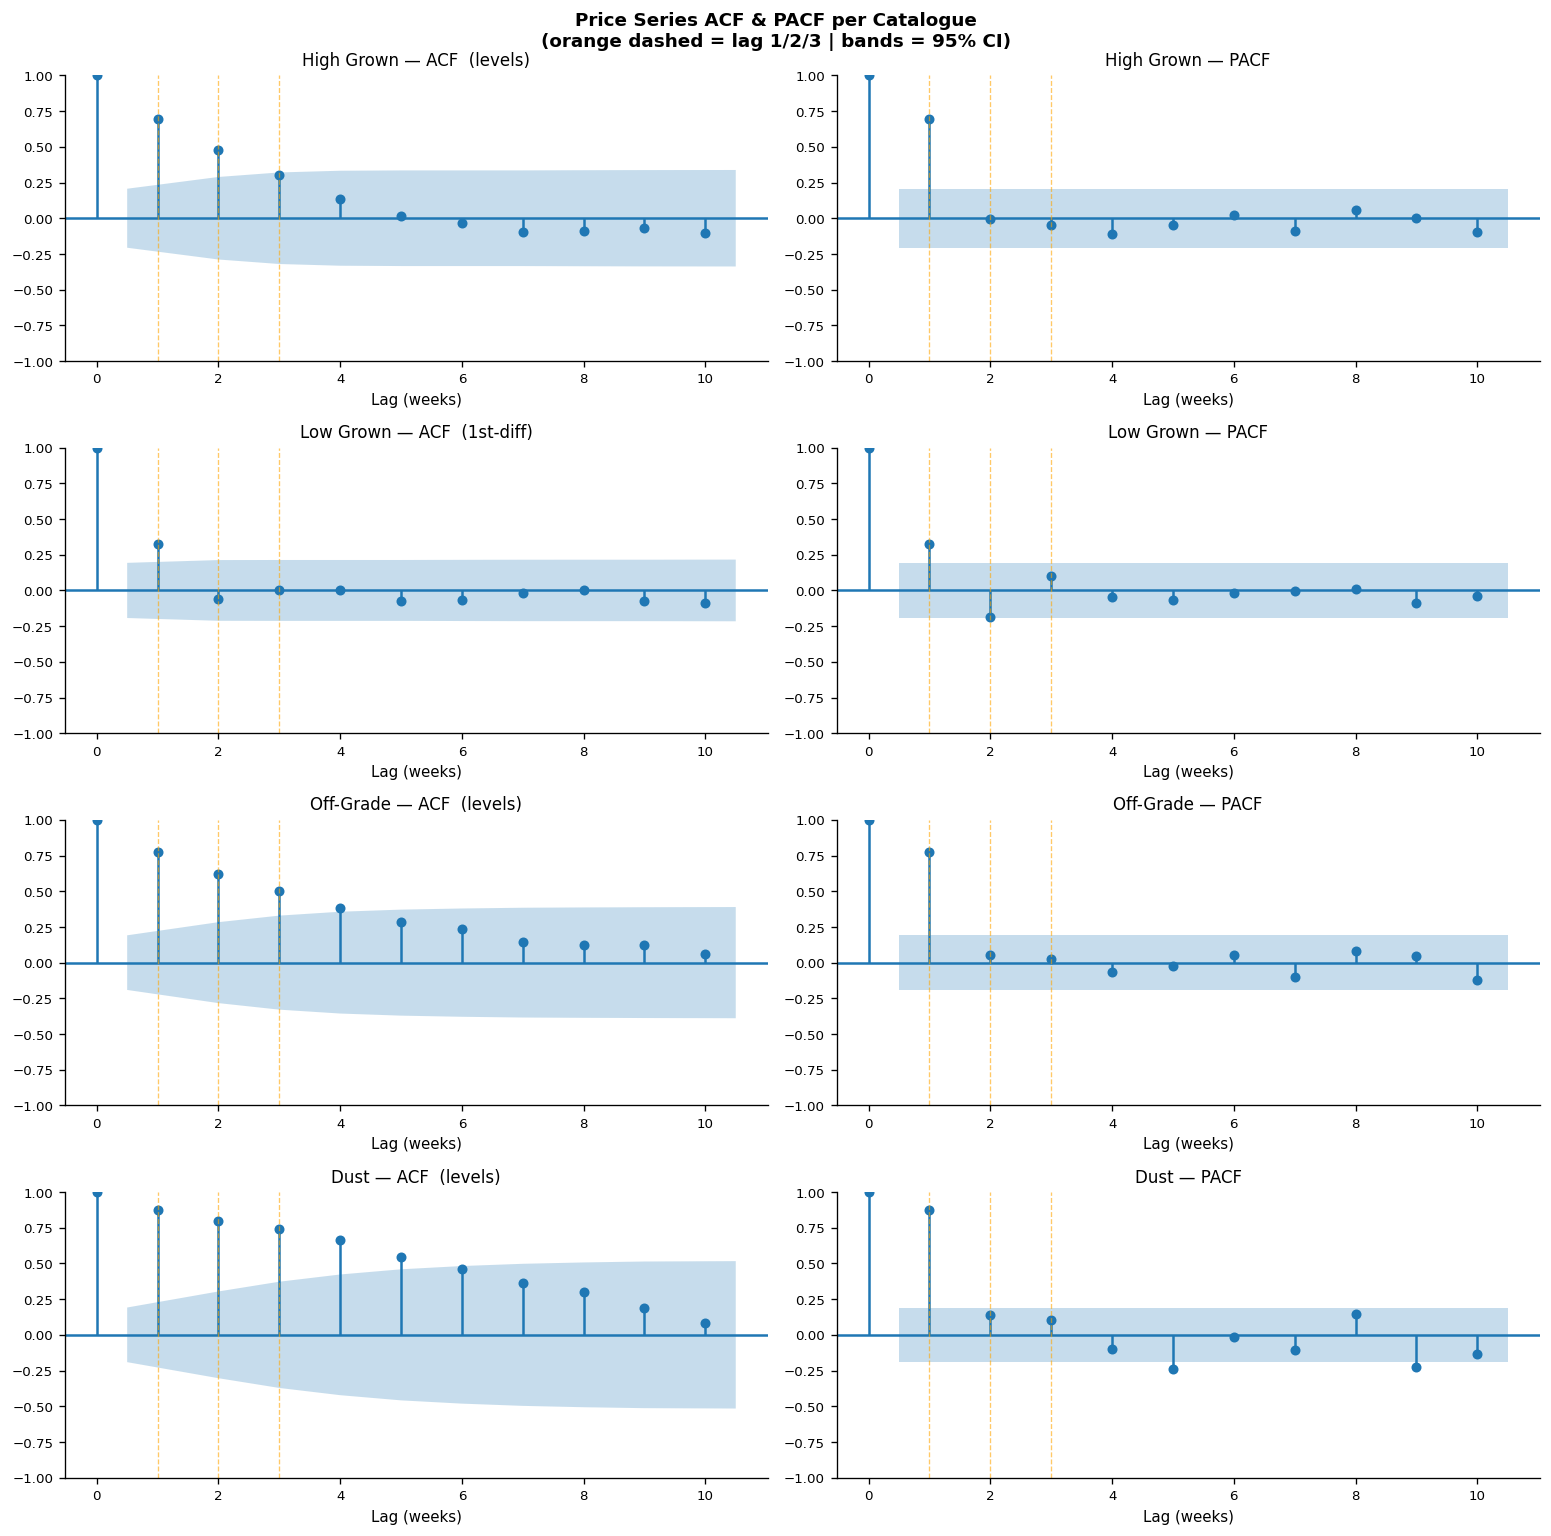

Saved: granger_acf_pacf.png


In [8]:
# ── 7. ACF / PACF — Price Autocorrelation per Catalogue ─────────────────────
# Shows which price lag orders carry predictive signal.

fig, axes = plt.subplots(4, 2, figsize=(13, 13))

for row_idx, cat in enumerate(CATALOGUES):
    ts   = catalogue_ts[cat]
    decs = stationarity_decisions[cat]
    price = ts['price_mid_lkr'].diff().dropna() if decs['price_diff'] \
            else ts['price_mid_lkr'].dropna()

    ax_acf  = axes[row_idx, 0]
    ax_pacf = axes[row_idx, 1]

    nlags = min(10, len(price) // 5)
    plot_acf(price,  lags=nlags, ax=ax_acf,  alpha=0.05,
             title=f'{DISP[cat]} — ACF'
                   f'  ({"1st-diff" if decs["price_diff"] else "levels"})')
    plot_pacf(price, lags=nlags, ax=ax_pacf, alpha=0.05, method='ywm',
              title=f'{DISP[cat]} — PACF')

    for ax in (ax_acf, ax_pacf):
        ax.set_xlabel('Lag (weeks)')
        for v_lag in [1, 2, 3]:
            ax.axvline(v_lag, color='orange', linewidth=0.8, linestyle='--', alpha=0.6)

fig.suptitle('Price Series ACF & PACF per Catalogue\n'
             '(orange dashed = lag 1/2/3 | bands = 95% CI)',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'granger_acf_pacf.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: granger_acf_pacf.png')

### 7b. P-value Heatmap

Colour = −log₁₀(p): darker = more significant.

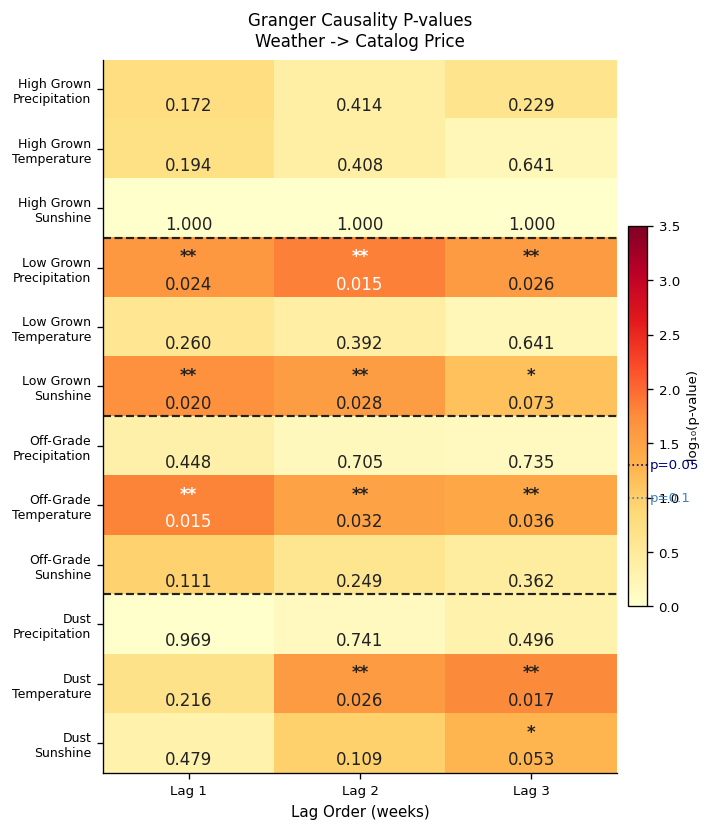

Saved: granger_pvalue_heatmap.png


In [17]:
# ── Fig A: P-value Heatmap ───────────────────────────────────────────────────
VARS_ORDER = ['Precipitation', 'Temperature', 'Sunshine']
LAGS_ORDER = list(range(1, MAX_LAG + 1))

row_labels = [f'{DISP[c]}\n{v}' for c in CATALOGUES for v in VARS_ORDER]
p_matrix   = []
for cat in CATALOGUES:
    for var in VARS_ORDER:
        row = []
        for lag in LAGS_ORDER:
            sel = results_df[
                (results_df['catalogue'] == cat) &
                (results_df['weather_var'] == var) &
                (results_df['lag'] == lag)
            ]['p_value'].values
            row.append(float(sel[0]) if len(sel) and not pd.isna(sel[0]) else 1.0)
        p_matrix.append(row)

p_arr   = np.array(p_matrix)
neg_log = -np.log10(np.clip(p_arr, 1e-4, 1.0))

fig, ax = plt.subplots(figsize=(6, 7))
im = ax.imshow(neg_log, aspect='auto', cmap='YlOrRd', vmin=0, vmax=3.5)

ax.set_xticks(range(len(LAGS_ORDER)))
ax.set_xticklabels([f'Lag {l}' for l in LAGS_ORDER])
ax.set_yticks(range(len(row_labels)))
ax.set_yticklabels(row_labels, fontsize=7.5)

for div in [3, 6, 9]:
    ax.axhline(div - 0.5, color='#222', linewidth=1.3, linestyle='--')

for i in range(p_arr.shape[0]):
    for j in range(p_arr.shape[1]):
        p     = p_arr[i, j]
        nlp   = neg_log[i, j]
        stars = '***' if p<0.01 else ('**' if p<0.05 else ('*' if p<0.10 else ''))
        tc    = 'white' if nlp > 1.8 else '#222'
        if stars:
            ax.text(j, i-0.18, stars, ha='center', va='center',
                    fontsize=10, fontweight='bold', color=tc)
        ax.text(j, i+0.28, f'{p:.3f}', ha='center', va='center',
                fontsize=10, color=tc)

cbar = fig.colorbar(im, ax=ax, fraction=0.035, pad=0.02)
cbar.set_label('-log\u2081\u2080(p-value)', fontsize=8)
for thresh, col in [(0.10, 'steelblue'), (0.05, 'navy')]:
    cbar.ax.axhline(-np.log10(thresh), color=col, linewidth=1, linestyle=':')
    cbar.ax.text(1.15, -np.log10(thresh), f'p={thresh}', va='center',
                 fontsize=8, color=col, transform=cbar.ax.transData)

ax.set_title('Granger Causality P-values\nWeather -> Catalog Price', pad=8)
ax.set_xlabel('Lag Order (weeks)')
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'granger_pvalue_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: granger_pvalue_heatmap.png')

### 7c. F-statistic Profiles Across Lag Orders

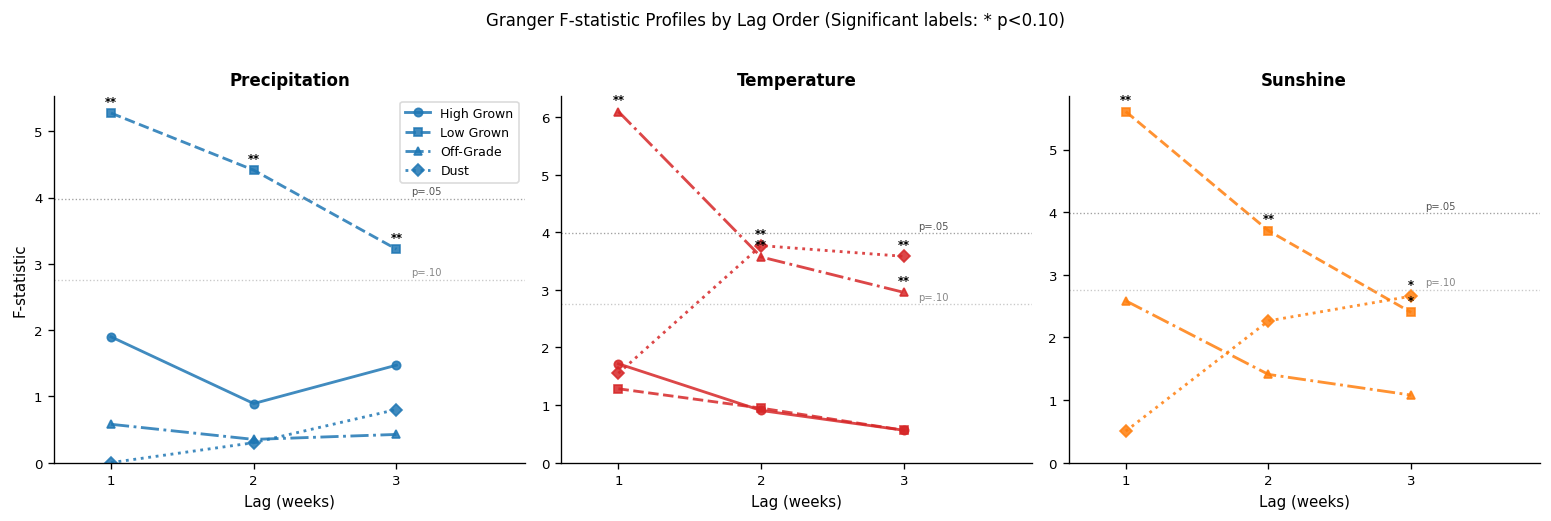

Saved: granger_fstat_profiles.png


In [10]:
# ── Fig B: F-statistic Profiles Across Lag Orders ────────────────────────────
VAR_COLORS = {'Precipitation':'#1f77b4','Temperature':'#d62728','Sunshine':'#ff7f0e'}
SEG_STYLES = {
    'high_grown': ('-',  'o'),
    'low_grown':  ('--', 's'),
    'off_grade':  ('-.', '^'),
    'dust':       (':',  'D'),
}

fig, axes = plt.subplots(1, 3, figsize=(13, 4.2), sharey=False)

for ai, var in enumerate(['Precipitation', 'Temperature', 'Sunshine']):
    ax = axes[ai]
    for cat in CATALOGUES:
        ls, mk = SEG_STYLES[cat]
        sub = results_df[
            (results_df['catalogue'] == cat) & (results_df['weather_var'] == var)
        ].sort_values('lag')
        ax.plot(sub['lag'], sub['F_stat'],
                color=VAR_COLORS[var], linestyle=ls, marker=mk,
                linewidth=1.7, markersize=5, label=DISP[cat], alpha=0.85)
        for _, r in sub.iterrows():
            if not pd.isna(r['p_value']) and r['p_value'] < 0.10:
                ax.annotate(
                    r['sig'], (r['lag'], r['F_stat']),
                    textcoords='offset points', xytext=(0, 5),
                    ha='center', fontsize=7, fontweight='bold'
                )

    # Approx critical F (n~80, df1=1, df2~70) for p=0.05 and p=0.10
    ax.axhline(3.98, color='#888', lw=0.8, ls=':', alpha=0.8)
    ax.axhline(2.76, color='#bbb', lw=0.8, ls=':', alpha=0.8)
    ax.text(MAX_LAG + 0.1, 4.05, 'p=.05', fontsize=6, color='#555')
    ax.text(MAX_LAG + 0.1, 2.83, 'p=.10', fontsize=6, color='#888')

    ax.set_title(var, fontweight='bold')
    ax.set_xlabel('Lag (weeks)')
    if ai == 0:
        ax.set_ylabel('F-statistic')
    ax.set_xticks(LAGS_ORDER)
    ax.set_xlim(0.6, MAX_LAG + 0.9)
    ax.set_ylim(bottom=0)

axes[0].legend(fontsize=7.5, framealpha=0.7)
fig.suptitle('Granger F-statistic Profiles by Lag Order (Significant labels: * p<0.10)',
             fontsize=10, y=1.02)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'granger_fstat_profiles.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: granger_fstat_profiles.png')

### 7d. Time-Series Overlays (Top Significant Pairs)

Top pairs selected for overlay plots:


,catalogue,weather_var,lag,F_stat,p_value,sig
0,low_grown,Precipitation,2,4.414,0.0147,**
1,off_grade,Temperature,1,6.097,0.0152,**
2,dust,Temperature,3,3.583,0.0167,**
3,low_grown,Sunshine,1,5.607,0.0199,**


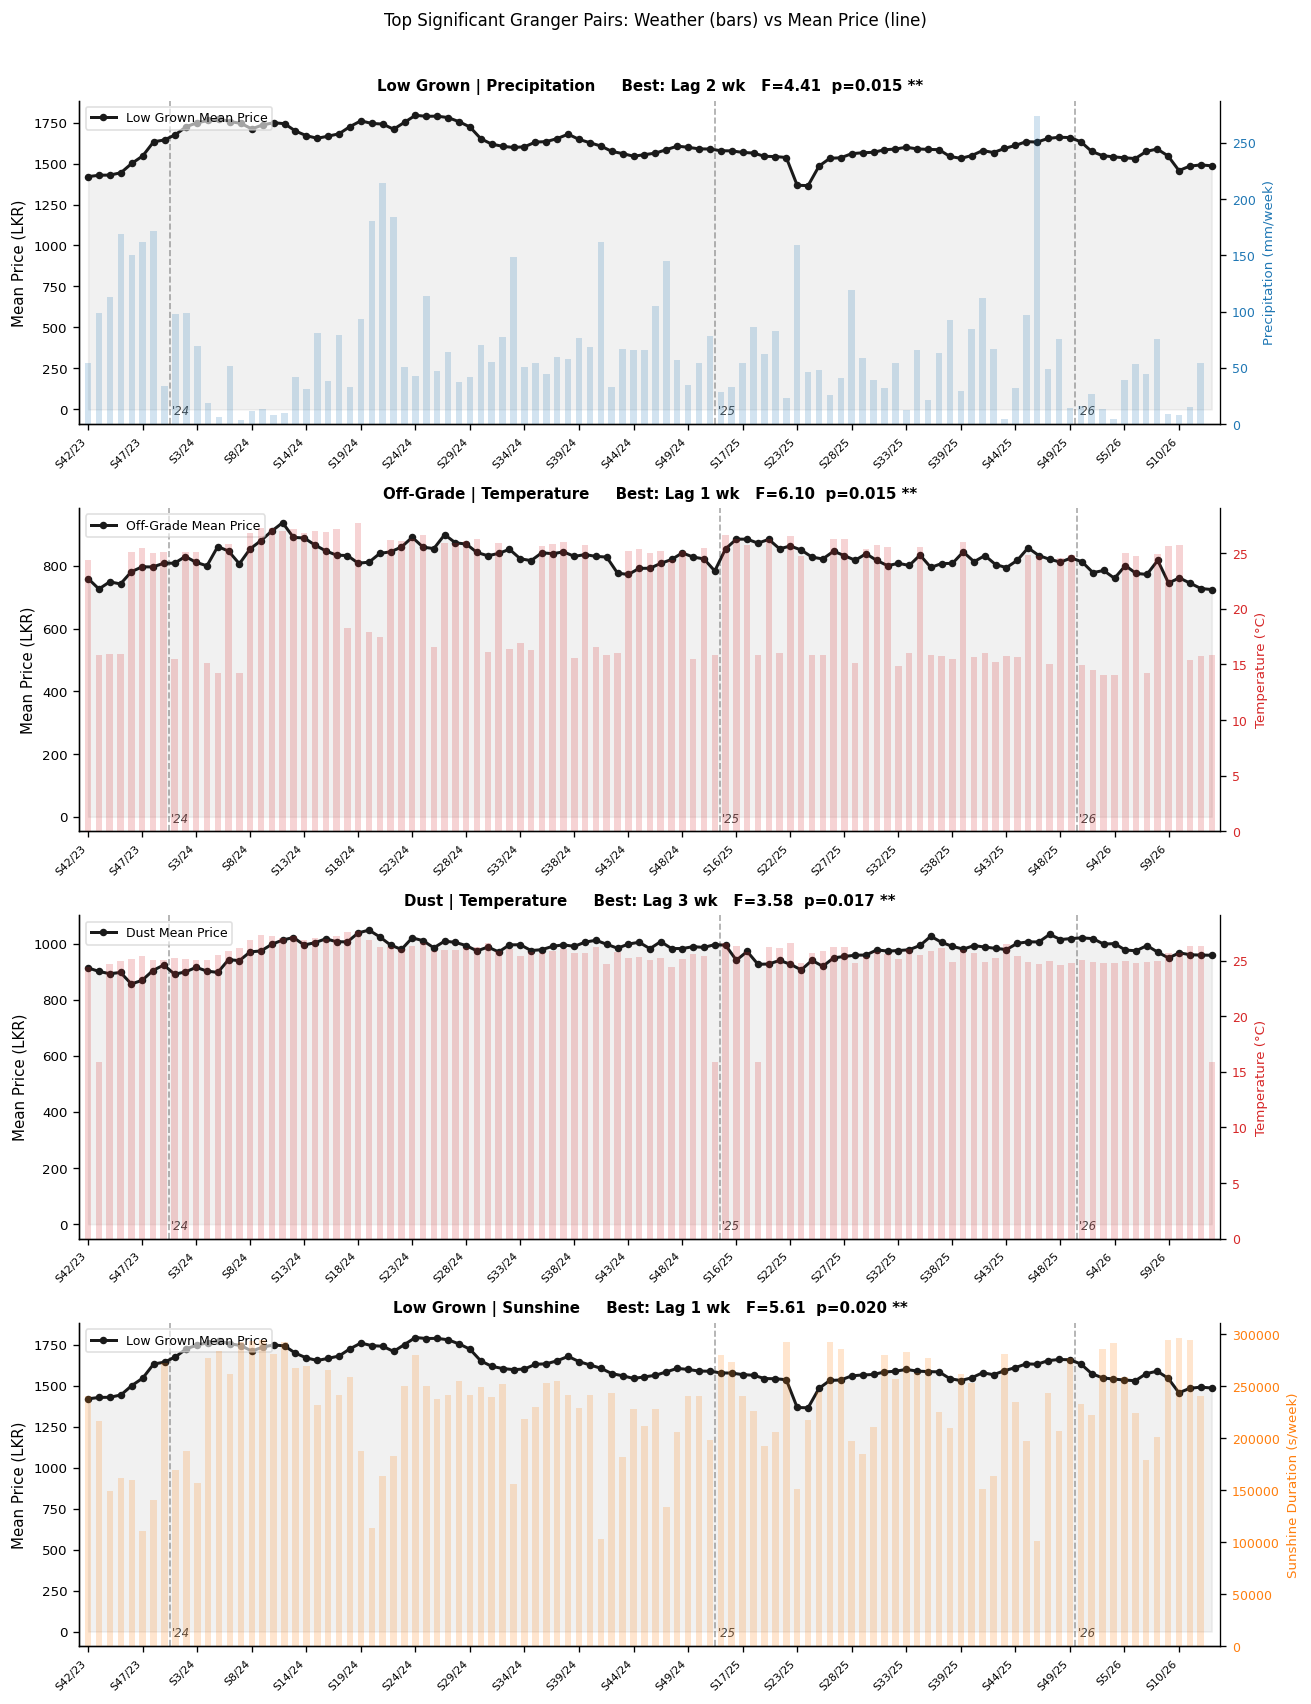

Saved: granger_timeseries_overlays.png


In [11]:
# ── Fig C: Time-Series Overlays for Top Significant Pairs ────────────────────
# Pick up to 4 pairs with lowest p-value for overlay plots.

top_pairs = (
    results_df.dropna(subset=['p_value'])
    .sort_values('p_value')
    .drop_duplicates(subset=['catalogue', 'weather_var'])  # one per pair
    .head(4)
    [['catalogue', 'weather_var', 'lag', 'F_stat', 'p_value', 'sig']]
    .reset_index(drop=True)
)

print('Top pairs selected for overlay plots:')
display(top_pairs)

WCOL_FOR_OVERLAY = {
    'Precipitation': ('precip_current',  'Precipitation (mm/week)', '#1f77b4'),
    'Temperature':   ('temperature_current','Temperature (\u00b0C)',     '#d62728'),
    'Sunshine':      ('sunshine_current', 'Sunshine Duration (s/week)','#ff7f0e'),
}

n_pairs = len(top_pairs)
fig, axes = plt.subplots(n_pairs, 1, figsize=(11, 3.5 * n_pairs))
if n_pairs == 1:
    axes = [axes]

for idx, pair_row in top_pairs.iterrows():
    ax1  = axes[idx]
    ax2  = ax1.twinx()
    ax2.spines['right'].set_visible(True)

    cat      = pair_row['catalogue']
    var_name = pair_row['weather_var']
    col, ylabel, color = WCOL_FOR_OVERLAY[var_name]

    ts       = catalogue_ts[cat]
    x_pos    = ts['time_idx'].values
    price_s  = ts['price_mid_lkr'].values
    w_series = ts[col].values if col in ts.columns else np.full(len(ts), np.nan)
    years    = ts['sale_year'].values

    ax2.bar(x_pos, w_series, color=color, alpha=0.20, width=0.6, zorder=1)
    ax2.set_ylabel(ylabel, color=color, fontsize=8)
    ax2.tick_params(axis='y', labelcolor=color, labelsize=7.5)

    ax1.plot(x_pos, price_s, color='#1a1a1a', linewidth=1.8,
             marker='o', markersize=3.5, zorder=3,
             label=f'{DISP[cat]} Mean Price')
    ax1.fill_between(x_pos, price_s, alpha=0.06, color='#1a1a1a', zorder=2)
    ax1.set_ylabel('Mean Price (LKR)', fontsize=9)

    for k in range(1, len(years)):
        if years[k] != years[k-1]:
            bx = (x_pos[k-1] + x_pos[k]) / 2
            ax1.axvline(bx, color='#555', lw=1, ls='--', alpha=0.5)
            ax1.text(bx+0.2, 0.02, f"'{str(int(years[k]))[-2:]}",
                     fontsize=7, color='#444', va='bottom', style='italic',
                     transform=ax1.get_xaxis_transform())

    tick_step = max(1, len(x_pos) // 20)
    ax1.set_xticks(x_pos[::tick_step])
    xlabels = [
        f"S{int(ts['sale_number'].iloc[i])}/{str(int(ts['sale_year'].iloc[i]))[-2:]}"
        for i in range(0, len(x_pos), tick_step)
    ]
    ax1.set_xticklabels(xlabels, rotation=45, ha='right', fontsize=6.5)
    ax1.set_xlim(x_pos[0]-0.8, x_pos[-1]+0.8)
    ax1.legend(loc='upper left', fontsize=7.5, framealpha=0.6)

    ax1.set_title(
        f'{DISP[cat]} | {var_name}     '
        f'Best: Lag {int(pair_row["lag"])} wk   '
        f'F={pair_row["F_stat"]:.2f}  p={pair_row["p_value"]:.3f} {pair_row["sig"]}',
        fontsize=9, fontweight='bold'
    )

fig.suptitle('Top Significant Granger Pairs: Weather (bars) vs Mean Price (line)',
             fontsize=10, y=1.01)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'granger_timeseries_overlays.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: granger_timeseries_overlays.png')

### 7e. ADF Stationarity Summary

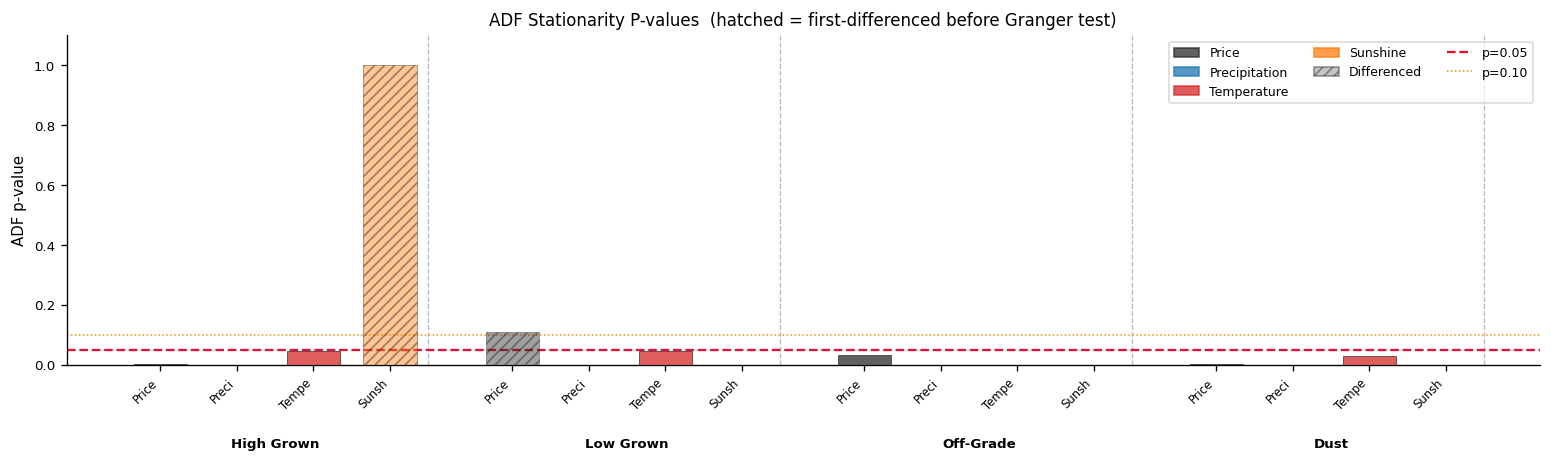

Saved: granger_adf_stationarity.png


In [12]:
# ── Fig D: ADF P-value Summary Bar Chart ─────────────────────────────────────
adf_recs = []
for cat in CATALOGUES:
    ts = catalogue_ts[cat]
    _, p_p = adf_result(ts['price_mid_lkr'])
    adf_recs.append({'label': f'{DISP[cat]}\nPrice', 'series': 'Price',
                     'cat': DISP[cat], 'adf_p': p_p,
                     'diffed': stationarity_decisions[cat]['price_diff']})
    for var_name, col in WEATHER_VARS.items():
        s = ts[col].dropna() if col in ts.columns else pd.Series(dtype=float)
        _, p_w = adf_result(s)
        adf_recs.append({'label': f'{DISP[cat]}\n{var_name[:5]}', 'series': var_name,
                         'cat': DISP[cat], 'adf_p': p_w,
                         'diffed': stationarity_decisions[cat].get(f'{var_name}_diff', False)})
adf_df = pd.DataFrame(adf_recs)

SCOL = {'Price':'#2c2c2c','Precipitation':'#1f77b4','Temperature':'#d62728','Sunshine':'#ff7f0e'}

fig, ax = plt.subplots(figsize=(13, 4))
x = 0
xt, xl, seg_info = [], [], []
for cat in CATALOGUES:
    seg_start = x
    cat_rows = adf_df[adf_df['cat'] == DISP[cat]]
    for _, r in cat_rows.iterrows():
        color  = SCOL[r['series']]
        height = float(r['adf_p']) if not pd.isna(r['adf_p']) else 1.0
        b = ax.bar(x, height, color=color, alpha=0.75 if not r['diffed'] else 0.45,
                   edgecolor='#222', linewidth=0.5, width=0.7, zorder=3)
        if r['diffed']:
            b[0].set_hatch('////')
        xt.append(x); xl.append(r['series'][:5])
        x += 1
    seg_info.append((seg_start, x-1, DISP[cat]))
    ax.axvline(x-0.5, color='#bbb', lw=0.8, ls='--')
    x += 0.6

ax.axhline(0.05, color='crimson',    lw=1.4, ls='--', label='p=0.05')
ax.axhline(0.10, color='darkorange', lw=0.9, ls=':',  label='p=0.10')
ax.set_xticks(xt); ax.set_xticklabels(xl, fontsize=7, rotation=45, ha='right')
ax.set_ylabel('ADF p-value'); ax.set_ylim(0, 1.1)
ax.set_title('ADF Stationarity P-values  (hatched = first-differenced before Granger test)')
for (s0, s1, name) in seg_info:
    ax.text((s0+s1)/2, -0.22, name, ha='center', va='top', fontsize=8, fontweight='bold',
            transform=ax.get_xaxis_transform())
patches = [mpatches.Patch(color=c, alpha=0.75, label=s) for s, c in SCOL.items()]
hdiff   = mpatches.Patch(facecolor='grey', hatch='////', edgecolor='#222', alpha=0.45, label='Differenced')
h, l = ax.get_legend_handles_labels()
ax.legend(handles=patches + [hdiff] + h, labels=list(SCOL)+['Differenced']+l,
          fontsize=7.5, loc='upper right', ncol=3, framealpha=0.7)
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'granger_adf_stationarity.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: granger_adf_stationarity.png')

## 8. Save Results & Interpretation

In [13]:
# ── Save all results & interpretation notes ──────────────────────────────────
results_df.to_csv(OUTPUT_DIR / 'granger_causality_full.csv', index=False)
summary_tbl.to_csv(OUTPUT_DIR / 'granger_causality_summary.csv', index=False)
print('Saved: granger_causality_full.csv  |  granger_causality_summary.csv')

print()
print('=' * 80)
print('  INTERPRETATION NOTES')
print('=' * 80)
n_total = len(results_df)
n01 = (results_df['p_value'] < 0.01).sum()
n05 = (results_df['p_value'] < 0.05).sum()
n10 = (results_df['p_value'] < 0.10).sum()
print(f'Total tests: {n_total}  (4 catalogues x 3 vars x {MAX_LAG} lags)')
print(f'  p<0.01: {n01}/{n_total}  |  p<0.05: {n05}/{n_total}  |  p<0.10: {n10}/{n_total}')
print()
for var in ['Precipitation', 'Temperature', 'Sunshine']:
    sig = results_df[(results_df['weather_var']==var) & (results_df['p_value']<0.10)]
    cats = sig['cat_display'].unique().tolist()
    if cats:
        best = sig.loc[sig['p_value'].idxmin()]
        print(f'  {var}: significant in {cats}')
        print(f'    Strongest: {best["cat_display"]}, Lag {int(best["lag"])}, '
              f'F={best["F_stat"]:.2f}, p={best["p_value"]:.3f} {best["sig"]}')
    else:
        print(f'  {var}: no significant Granger causality (p<0.10) across any catalogue')
print()
print('Limitations:')
print('  - Granger causality is predictive, not structural causal.')
print('  - ADF-guided differencing applied before each test.')
print('  - Reconstruction of current precip/sunshine via lag1 shift(-1) loses 1 obs per catalogue.')
print('  - Price series are aggregate (mean across all grades/tiers per catalogue per sale).')

Saved: granger_causality_full.csv  |  granger_causality_summary.csv

  INTERPRETATION NOTES
Total tests: 36  (4 catalogues x 3 vars x 3 lags)
  p<0.01: 0/36  |  p<0.05: 10/36  |  p<0.10: 12/36

  Precipitation: significant in ['Low Grown']
    Strongest: Low Grown, Lag 2, F=4.41, p=0.015 **
  Temperature: significant in ['Off-Grade', 'Dust']
    Strongest: Off-Grade, Lag 1, F=6.10, p=0.015 **
  Sunshine: significant in ['Low Grown', 'Dust']
    Strongest: Low Grown, Lag 1, F=5.61, p=0.020 **

Limitations:
  - Granger causality is predictive, not structural causal.
  - ADF-guided differencing applied before each test.
  - Reconstruction of current precip/sunshine via lag1 shift(-1) loses 1 obs per catalogue.
  - Price series are aggregate (mean across all grades/tiers per catalogue per sale).
